# A/B 테스트 종합 과제 — 랜딩 페이지 전환율 분석

**데이터셋:** Kaggle - Landing Page A/B Testing (`ab_data.csv`)
🔗 https://www.kaggle.com/datasets/zhangluyuan/ab-testing
**내려받은 날짜:** `2026-08-09`

---
## 분석 목표
새 랜딩 페이지(`new_page`)가 기존(`old_page`)보다 **전환율**을 높이는지 검정하고,
**출시 / 보류 / 추가 수집** 중 하나를 근거와 함께 제안한다.

> ✅ 재현성: 난수 고정(`np.random.seed`) + 처음부터 다시 실행해도 동일 결과.

## 0. 라이브러리

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy.optimize import brentq

np.random.seed(42)   # 재현성
plt.rcParams['axes.unicode_minus'] = False

---
# 1️⃣ 데이터 위생 점검
> 💡 검정보다 **먼저**. 데이터가 오염돼 있으면 p값은 무의미하다.
점검: ① 기본 ② 중복 ③ 배정 일관성 ④ SRM

In [2]:
df = pd.read_csv('ab_data.csv')   # ← 경로를 본인 환경에 맞게 수정
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### ① 기본 확인 — 행 수·컬럼·자료형·결측치

In [3]:
print(f"행 수: {len(df):,}, 컬럼 수: {df.shape[1]}")
print("\n[자료형]"); print(df.dtypes)
print("\n[결측치]"); print(df.isnull().sum())

행 수: 294,478, 컬럼 수: 5

[자료형]
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

[결측치]
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


**📝 결과:** 294,478행 · 컬럼 5개 · 결측치 0 · 자료형 정상(`converted`=0/1)

### ② 중복 확인 — 같은 user_id가 두 번 이상?

In [4]:
dup = df['user_id'].duplicated().sum()
print(f"중복 등장 행: {dup:,} / 고유 user_id: {df['user_id'].nunique():,}")

중복 등장 행: 3,894 / 고유 user_id: 290,584


**📝 결과:** 중복 3,894행 → 한 사용자=한 번만 집계해야 하므로 정제 대상.

### ③ 배정 일관성 — 처치 라벨이 어긋난 행은?
정상: `control`→`old_page`, `treatment`→`new_page`

In [5]:
print(pd.crosstab(df['group'], df['landing_page']))
mismatch = df[((df['group']=='control')   & (df['landing_page']=='new_page')) |
              ((df['group']=='treatment') & (df['landing_page']=='old_page'))]
print(f"\n어긋난 행: {len(mismatch):,}")

landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

어긋난 행: 3,893


**📝 결과:** 어긋난 행 3,893개 → 어떤 처치를 받았는지 신뢰 불가 → 제거.

### ④ SRM 점검 — 배정 비율이 50:50인가?


In [6]:
counts = df['group'].value_counts(); print(counts)
n_c0, n_t0 = counts['control'], counts['treatment']
chi2_srm, p_srm = stats.chisquare([n_c0, n_t0], [(n_c0+n_t0)/2]*2)
print(f"\nchi2={chi2_srm:.4f}, p={p_srm:.4f}")
print("→ p>0.05: 50:50 배정 정상 ✅" if p_srm>0.05 else "→ SRM 발생!")

group
treatment    147276
control      147202
Name: count, dtype: int64

chi2=0.0186, p=0.8915
→ p>0.05: 50:50 배정 정상 ✅


**📝 결과:** control 147,202 vs treatment 147,276 → **p=0.8915(>0.05)** → 배정 정상 ✅

### 🧹 정제 — 어긋난 행 & 중복 제거
> 필수: 제거 이유 + 정제 전후 행 수 기록

In [7]:
before = len(df); print(f"정제 전: {before:,}행")
# (1) 어긋난 행 제거: group↔landing_page 모순 → 처치 신뢰 불가
consistent = ((df['group']=='control')   & (df['landing_page']=='old_page')) | \
             ((df['group']=='treatment') & (df['landing_page']=='new_page'))
df = df[consistent].copy()
print(f"어긋난 행 제거 후: {len(df):,}행 (제거 {before-len(df):,})")
# (2) 중복 제거: 한 사용자=한 번 (첫 등장 유지)
step = len(df)
df = df.drop_duplicates(subset='user_id', keep='first').copy()
print(f"중복 제거 후: {len(df):,}행 (제거 {step-len(df):,})")
print(f"\n✅ 최종: {len(df):,}행 (전체 {before:,} 중 {before-len(df):,} 제거)")

정제 전: 294,478행
어긋난 행 제거 후: 290,585행 (제거 3,893)
중복 제거 후: 290,584행 (제거 1)

✅ 최종: 290,584행 (전체 294,478 중 3,894 제거)


**📝 정제 요약**

| 처리 | 이유 | 제거 |
|---|---|---|
| 어긋난 행 | group↔page 모순 | 3,893 |
| 중복 user_id | 한 사용자=한 번 | 1 |
| **전 → 후** | | **294,478 → 290,584** |

---
# 2️⃣ 질문과 가설


**알고 싶은 것 (한 문장):**
"새 랜딩 페이지(new_page)는 기존 페이지(old_page)보다 전환율을 높이는가?"

**가설**
- 귀무가설 $H_0$: 새 페이지와 기존 페이지의 전환율은 **같다.**
- 대립가설 $H_1$: 두 페이지의 전환율은 **다르다.**

**유의수준 · 검정 방향**
- $\alpha = 0.05$
- **양측검정** — "높인다"가 아니라 "다른가"를 보므로. (새 페이지가 더 나쁠 가능성도 열어둠)

---
# 3️⃣ 검정 고르기 
아래 3가지 질문으로 검정을 결정한다.

1. **성공 지표 유형?** → `converted`는 전환 여부(0/1) = **비율(범주형)**
2. **집단 수?** → control vs treatment = **2집단**
3. (연속형이면 정규성·등분산 확인 필요하지만, 여기선 비율이므로 해당 없음)

→ **비율 · 2집단 → 카이제곱 독립성 검정** (그룹 × 전환여부)

###  검정 선택 근거 
> 카이제곱 검정을 골랐다. 왜냐하면 성공지표가 전환 여부(0/1)라는 비율(범주형) 데이터이고, 비교집단이 control/treatment 2집단이기 때문이다. 
> 평균을 비교하는 t검정이나 ANOVA는 매출·시간 같은 연속형 지표에 쓰는 것이라 여기엔 맞지 않는다. 
> 또한 두 변수(그룹 × 전환여부)가 서로 관련 있는지 보는 것이므로 카이제곱 중에서도 독립성 검정에 해당한다.


---
# 4️⃣ 검정 수행 + 3종 세트 보고
p값 하나로 끝내지 않고 **① 점추정 ② 95% 신뢰구간 ③ 효과크기**를 함께 본다.

In [8]:
# 그룹별 집계
g = df.groupby('group')['converted'].agg(['count','sum','mean'])
n_c, x_c, p_c = g.loc['control','count'],   g.loc['control','sum'],   g.loc['control','mean']
n_t, x_t, p_t = g.loc['treatment','count'], g.loc['treatment','sum'], g.loc['treatment','mean']
print(g)
print(f"\ncontrol(기존)   전환율: {p_c:.4f}")
print(f"treatment(새)   전환율: {p_t:.4f}")

            count    sum      mean
group                             
control    145274  17489  0.120386
treatment  145310  17264  0.118808

control(기존)   전환율: 0.1204
treatment(새)   전환율: 0.1188


### 카이제곱 독립성 검정

In [9]:
cont = pd.crosstab(df['group'], df['converted'])
print("[분할표]"); print(cont)
chi2, p, dof, expected = stats.chi2_contingency(cont, correction=False)
print(f"\nchi2({dof}) = {chi2:.4f},  p = {p:.4f}")

# 효과크기: Cramér's V
n = cont.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(cont.shape)-1)))
print(f"Cramér's V = {cramers_v:.4f}  (0에 가까울수록 효과 미미)")

[분할표]
converted       0      1
group                   
control    127785  17489
treatment  128046  17264

chi2(1) = 1.7185,  p = 0.1899
Cramér's V = 0.0024  (0에 가까울수록 효과 미미)


### 3종 세트: 점추정 · 95% 신뢰구간 · 효과크기

In [10]:
# ① 점추정 (절대차 %p, 상대차 배수) — 비율은 둘 다 적는다
diff = p_t - p_c
rel  = p_t / p_c
print(f"① 절대차: {diff*100:+.3f}%p")
print(f"   상대차: {rel:.4f}배 ({(rel-1)*100:+.2f}%)")

# ② 95% 신뢰구간 (두 비율 차이)
se = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
ci = (diff - 1.96*se, diff + 1.96*se)
print(f"② 95% CI: [{ci[0]*100:+.3f}%p, {ci[1]*100:+.3f}%p]")
print("   → CI가 0을 포함" + (" (유의하지 않음)" if ci[0] < 0 < ci[1] else ""))

# ③ 효과크기
print(f"③ 효과크기 Cramér's V = {cramers_v:.4f}")

① 절대차: -0.158%p
   상대차: 0.9869배 (-1.31%)
② 95% CI: [-0.394%p, +0.078%p]
   → CI가 0을 포함 (유의하지 않음)
③ 효과크기 Cramér's V = 0.0024


**📝 결과 요약 (보고 문장)**
- 새 페이지의 전환율이 기존보다 오히려 살짝 낮았다 (11.88% vs 12.04%).
- `−0.158%p (상대 −1.31%), χ²(1)=1.72, p=0.190, Cramér's V=0.002`
- 95% 신뢰구간 [−0.394%p, +0.078%p]는 **0을 포함** → 통계적으로 유의한 차이 없음.

- p=0.19 > 0.05 → 귀무가설 기각 **못 함**
- 효과크기도 거의 0 → 실질적으로도 차이 미미

### 📊 시각화 — 그룹별 전환율 + 95% CI

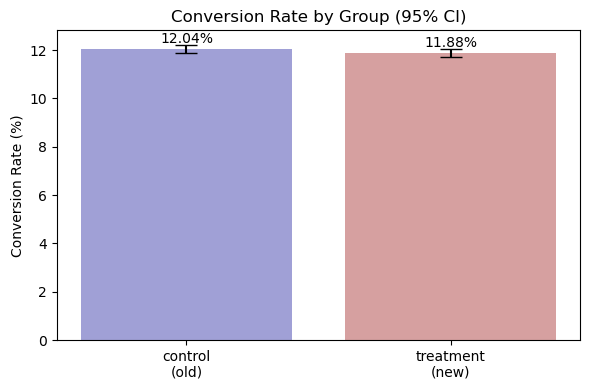

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
groups = ['control\n(old)', 'treatment\n(new)']
rates = [p_c*100, p_t*100]
errs = [1.96*np.sqrt(p_c*(1-p_c)/n_c)*100, 1.96*np.sqrt(p_t*(1-p_t)/n_t)*100]
ax.bar(groups, rates, yerr=errs, capsize=8, color=['#8888cc','#cc8888'], alpha=0.8)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Group (95% CI)')
for i,(r,e) in enumerate(zip(rates,errs)):
    ax.text(i, r+e+0.1, f'{r:.2f}%', ha='center')
plt.tight_layout(); plt.show()

---
# 5️⃣ 한 걸음 더 — [선택 A] 검정력 · MDE

> p ≥ 0.05가 나왔다. 이게 "효과가 없다"인가, "확인할 힘이 없었다"인가?
> **MDE(최소 검출 가능 효과)**를 구하면 둘을 구분할 수 있다.
> (사후 검정력은 계산하지 않는다 — 관측 p값의 재탕일 뿐.)

In [12]:
analysis = NormalIndPower()
# 이 표본 크기(nobs1=n_c)로 검정력 80%를 달성하는 최소 효과크기 h
h_min = analysis.solve_power(nobs1=n_c, alpha=0.05, power=0.8,
                             ratio=n_t/n_c, alternative='two-sided')
# h를 전환율 차이(%p)로 환산 (control 전환율 기준)
p2 = brentq(lambda x: proportion_effectsize(x, p_c) - h_min, p_c, 0.5)
mde_pp = (p2 - p_c) * 100
print(f"검출 가능한 최소 효과크기 h = {h_min:.5f}")
print(f"→ MDE ≈ {mde_pp:.3f}%p")
print(f"\n결론: 우리 표본(그룹당 약 {n_c:,}명)은")
print(f"      약 {mde_pp:.2f}%p 이상의 효과만 검출할 수 있었다.")

검출 가능한 최소 효과크기 h = 0.01039
→ MDE ≈ 0.340%p

결론: 우리 표본(그룹당 약 145,274명)은
      약 0.34%p 이상의 효과만 검출할 수 있었다.


**📝 해석**
- 우리 표본으로 검출 가능한 최소 효과 ≈ **0.34%p**.
- 관측된 차이(−0.16%p)는 이 문턱보다 작음 → "유의하지 않다"는 결과가 **표본 부족 탓이라 보기 어렵다.**
  (0.34%p 정도 큰 효과였다면 잡아냈을 텐데, 실제 차이는 그보다 작고 심지어 음수)
- 즉 "효과가 없다"에 가까운 결론. 표본을 더 모아도 유의미한 개선이 나올 가능성은 낮음.

---
# 6️⃣ 의사결정으로 마무리

### 1. 질문과 가설
새 랜딩 페이지가 전환율을 높이는가? $H_0$: 같다 / $H_1$: 다르다 (α=0.05, 양측)

### 2. 데이터 위생 점검
배정 어긋난 행 3,893개 + 중복 1개 제거 (294,478 → 290,584). SRM p=0.89로 배정 정상.

### 3. 검정 선택 근거
성공 지표가 전환 여부(비율)·2집단 → 카이제곱 독립성 검정.

### 4. 결과
전환율 11.88%(new) vs 12.04%(old). 절대차 −0.16%p, 95% CI [−0.39, +0.08]%p (0 포함),
χ²(1)=1.72, p=0.19, Cramér's V=0.002.

### 5. 의사결정
p=0.19로 유의하지않고, 방향도 음수이며, 효과크기도 0에 가깝고, MDE 분석상 표본 부족 탓도 아니다. 그렇기때문에 보류하는 것이 좋아보인다.

### 6. 한계 
- 전환이라는 것이 정확히 어떤것인지 정의하지 못한다.
- 실험 기간이 짧을수있다.
- 세그먼트(기기, 유입경로, 요일)별로는 결과가 다를수있는데, 전체만 봤다.